In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

### Part 3A — Experiment setup (hyperparameters + device)

- **Reproducibility**
  - `SEED = 42` and `torch.manual_seed(SEED)` are used to make training results more consistent across runs (same initialization and randomness where possible).

- **Dataset paths**
  - `train_dir = "train"` and `test_dir = "test"` define the folder locations expected by `ImageFolder`.
  - (In this notebook we mainly use `train_dir` and create a validation split from it; `test_dir` can be used later for final evaluation.)

- **Core training configuration**
  - `img_size = 48`: all images are resized to **48×48** for a fixed input shape.
  - `batch_size = 128`: mini-batch size used in training and validation loaders.
  - `latent_dim = 64`: dimensionality of the latent space (*z*). Larger values can increase capacity but may reduce disentanglement.
  - `epochs = 60`: maximum number of training epochs (early stopping may stop sooner).
  - `lr = 2e-3`: learning rate for the optimizer.

- **β-VAE / KL control**
  - `beta_final = 4.0`: final weight of the KL-divergence term (β-VAE).  
    Higher β → stronger regularization/disentanglement but usually worse reconstructions.
  - `warmup_epochs = 15`: KL warm-up length (β increases gradually from 0 → `beta_final`), improving stability and preventing early KL domination.
  - `patience = 8`: early stopping patience based on validation loss.

- **Compute device**
  - The model trains on GPU if available, otherwise CPU:
    - `device = cuda` if possible, else `cpu`
  - The printed output confirms the selected device.


In [7]:
SEED = 42
torch.manual_seed(SEED)

train_dir = "train"
test_dir  = "test"

img_size = 48
batch_size = 128
latent_dim = 64          # try 32/64/128
epochs = 60
lr = 2e-3
beta_final = 4.0         # for beta-VAE try: 0.5, 1, 4, 10
warmup_epochs = 15       # KL warm-up (very important)
patience = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Part 3A — Data preprocessing, dataset loading, and train/validation split

- **Image transformations**
  - `Grayscale(num_output_channels=1)`: converts images to 1-channel grayscale (simplifies the VAE input/output).
  - `Resize((img_size, img_size))`: resizes every image to **48×48** so the CNN architecture has a fixed input shape.
  - `ToTensor()`: converts images to PyTorch tensors and scales pixel values to **[0, 1]**, which matches the reconstruction loss setup (BCE with logits).

- **Dataset loading**
  - `datasets.ImageFolder(train_dir, transform=transform)` loads images from the `train/` directory using folder names as class labels.
  - Even though VAE training is **unsupervised**, `ImageFolder` is convenient for loading images; the labels are ignored during training.

- **Validation split**
  - We create a validation set from the training data:
    - `val_ratio = 0.1` → **10%** validation, **90%** training
  - This validation set is used for:
    - monitoring generalization (val loss)
    - early stopping
    - selecting the best model checkpoint

- **DataLoaders**
  - `train_loader`: `shuffle=True` to randomize batches during training.
  - `val_loader`: `shuffle=False` for stable evaluation.
  - `num_workers=2`: parallel data loading to speed up input pipeline.
  - `pin_memory=True`: can improve host→GPU transfer speed when training on CUDA.


In [8]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),  # keeps [0,1]
])

full_train = datasets.ImageFolder(train_dir, transform=transform)

# Create a validation split from train
val_ratio = 0.1
val_size = int(len(full_train) * val_ratio)
train_size = len(full_train) - val_size
train_data, val_data = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

### Part 3A — VAE model architecture (`ProVAE`)

- **Goal**
  - This class implements a **Variational Autoencoder (VAE)** for 48×48 grayscale images.
  - The model learns a compressed **latent representation** `z` (size = `latent_dim`) and reconstructs the input image.

- **Encoder (CNN)**
  - The encoder downsamples the input through 4 strided convolution blocks:
    - 48 → 24 → 12 → 6 → 3 (spatial resolution)
  - Each block uses:
    - `Conv2d` (stride=2) for downsampling
    - `BatchNorm2d` for training stability
    - `LeakyReLU` for nonlinearity
  - Output feature map shape becomes **(256, 3, 3)**, then flattened.

- **Latent distribution parameters**
  - The encoder outputs parameters of the approximate posterior:
    - `μ = fc_mu(h)`
    - `log(σ²) = fc_logvar(h)`
  - These represent the Gaussian distribution:  
    \[
    q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)
    \]

- **Reparameterization trick**
  - To allow backpropagation through sampling, we sample:
    \[
    z = \mu + \sigma \odot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
    \]
  - `logvar` is clamped to `[-10, 10]` to improve numerical stability and prevent exploding variance.

- **Decoder (CNN Transpose)**
  - The decoder maps `z` back to image space:
    - `fc_dec(z)` reshapes to (256, 3, 3)
    - then 4 transpose-convolution blocks upsample:
      - 3 → 6 → 12 → 24 → 48
  - The final layer outputs **logits** (no sigmoid inside the network).

- **Why output logits?**
  - Reconstruction loss uses `BCEWithLogitsLoss`, which expects logits (more stable than applying sigmoid in the model).
  - For visualization, `sigmoid(logits)` is applied later to convert output to pixel values in **[0,1]**.

- **Forward pass output**
  - `forward(x)` returns:
    - `logits` (reconstruction in logit space)
    - `mu` and `logvar` (latent distribution parameters)


In [9]:
class ProVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # 48 -> 24 -> 12 -> 6 -> 3
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc_mu     = nn.Linear(256 * 3 * 3, latent_dim)
        self.fc_logvar = nn.Linear(256 * 3 * 3, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 256 * 3 * 3)

        # Decoder outputs LOGITS (no Sigmoid here!)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)  # logits
        )

    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # clamp for stability (prevents exploding std)
        logvar = torch.clamp(logvar, -10, 10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z):
        h = self.fc_dec(z).view(-1, 256, 3, 3)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar


### Part 3A — VAE objective function (Reconstruction + KL divergence)

- **Reconstruction loss (data term)**
  - We use `BCEWithLogitsLoss(reduction="sum")`:
    - expects **logits** as model output (no sigmoid inside the decoder)
    - compares reconstructed logits to the true image pixels `x` in **[0, 1]**
  - `reduction="sum"` sums the pixel-wise loss across the entire batch.
  - Later in training, we divide by the number of samples so losses are comparable across epochs.

- **KL divergence (regularization term)**
  - The KL term measures how far the encoder’s posterior \( q(z|x) = \mathcal{N}(\mu, \sigma^2) \) is from the prior \( p(z) = \mathcal{N}(0, I) \):
    \[
    KL\big(q(z|x)\,\|\,p(z)\big)
    = -\frac{1}{2}\sum \left(1 + \log\sigma^2 - \mu^2 - \sigma^2\right)
    \]
  - This encourages a smooth, structured latent space and enables meaningful sampling.

- **β-VAE control (disentanglement vs. reconstruction trade-off)**
  - The total loss is:
    \[
    \mathcal{L} = \text{Recon} + \beta \cdot KL
    \]
  - Increasing **β** typically:
    - increases latent regularization / disentanglement
    - but can reduce reconstruction quality (more blurry / less accurate)

- **Outputs returned**
  - The function returns:
    - `total_loss = recon + beta * kl`
    - `recon` (for monitoring reconstruction quality)
    - `kl` (for monitoring latent regularization strength)


In [10]:
bce_logits = nn.BCEWithLogitsLoss(reduction="sum")

def vae_loss_from_logits(logits, x, mu, logvar, beta=1.0):
    # recon term
    recon = bce_logits(logits, x)

    # KL term (sum over batch+latent)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon + beta * kl, recon, kl

### Part 3C — Qualitative evaluation: reconstructions, random sampling, and interpolation

This cell defines three visualization utilities to **assess VAE quality beyond loss numbers**.  
All functions are wrapped with `@torch.no_grad()` to disable gradient tracking (faster + less memory).

- **1) `show_reconstructions(model, loader, n=10)`**
  - Takes a batch of real images from a loader.
  - Runs them through the VAE to obtain reconstruction **logits**.
  - Applies `sigmoid(logits)` to convert outputs to pixel intensities in **[0, 1]**.
  - Displays:
    - **Top row:** original images
    - **Bottom row:** reconstructed images
  - ✅ Purpose: check how well the VAE preserves key structure (shape, edges, intensity).

- **2) `show_generated(model, n=10)`**
  - Samples random latent vectors:
    \[
    z \sim \mathcal{N}(0, I)
    \]
  - Decodes them into image logits and applies sigmoid for visualization.
  - Displays randomly generated samples in one row.
  - ✅ Purpose: verify that the latent space learned a meaningful generative model (not just copying inputs).

- **3) `interpolate_real(model, loader, steps=10)`**
  - Picks two real images from a batch.
  - Encodes each to obtain their latent means \(\mu_1\) and \(\mu_2\).
  - Interpolates linearly between the two latent codes:
    \[
    z(t) = (1-t)\mu_1 + t\mu_2,\quad t \in [0,1]
    \]
  - Decodes each interpolated latent vector to visualize a smooth transition.
  - ✅ Purpose: test whether the latent space is **continuous and structured** (a core VAE property).

📌 These qualitative plots are typically required in VAE assignments to demonstrate:
- reconstruction ability (autoencoding)
- generation ability (sampling from prior)
- smooth latent manifold (interpolation)


In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, n=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    logits, _, _ = model(x)
    recon = torch.sigmoid(logits)  # convert logits -> [0,1]

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # original
        plt.subplot(2, n, i+1)
        plt.imshow(x[i,0].detach().cpu(), cmap="gray")
        plt.axis("off")
        # recon
        plt.subplot(2, n, n+i+1)
        plt.imshow(recon[i,0].detach().cpu(), cmap="gray")
        plt.axis("off")
    plt.suptitle("Top: Original | Bottom: Reconstruction")
    plt.show()

@torch.no_grad()
def show_generated(model, n=10):
    model.eval()
    z = torch.randn(n, model.latent_dim, device=device)
    logits = model.decode_logits(z)
    imgs = torch.sigmoid(logits).detach().cpu()

    plt.figure(figsize=(2*n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(imgs[i,0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Random Samples")
    plt.show()

@torch.no_grad()
def interpolate_real(model, loader, steps=10):
    """
    Better than interpolating two random z's:
    pick 2 real images -> encode -> interpolate between their latent codes
    """
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)

    x1 = x[0:1]
    x2 = x[1:2]

    mu1, logvar1 = model.encode(x1)
    mu2, logvar2 = model.encode(x2)

    # Use mu for cleaner interpolation
    z1, z2 = mu1, mu2

    plt.figure(figsize=(2*steps, 2))
    for i, t in enumerate(torch.linspace(0, 1, steps, device=device)):
        z = (1 - t) * z1 + t * z2
        logits = model.decode_logits(z)
        img = torch.sigmoid(logits)[0,0].detach().cpu()

        plt.subplot(1, steps, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle("Interpolation (real image A -> real image B)")
    plt.show()


### Part 3B — Training loop with KL warm-up, validation tracking, LR scheduling, and early stopping

This cell defines `train_vae(...)`, a full training routine for the VAE that is designed for **stability** and **good generalization**.

- **Optimizer**
  - Uses `AdamW` (Adam + weight decay) for more stable training:
    - `lr = 2e-3`
    - `weight_decay = 1e-4` helps reduce overfitting.

- **Learning-rate scheduler**
  - `ReduceLROnPlateau` monitors **validation loss** and reduces the learning rate when progress stalls:
    - `factor=0.5` reduces LR by half
    - `patience=2` waits 2 epochs without improvement before reducing LR.

- **KL warm-up (β schedule)**
  - β increases gradually from 0 to `beta_final` during the first `warmup_epochs`:
    \[
    \beta_{ep} = \beta_{final} \cdot \min\left(1,\frac{ep}{warmup\_epochs}\right)
    \]
  - This prevents KL from dominating too early and helps the model learn good reconstructions first.

- **Training step**
  - For each batch:
    - forward pass → `logits, mu, logvar`
    - compute total loss: `recon + β * KL`
    - backpropagation
    - **gradient clipping** (`clip_grad_norm_ = 5.0`) to prevent exploding gradients.

- **Loss tracking (normalized)**
  - Reconstruction loss, KL loss, and total loss are accumulated and then divided by the number of samples:
    - makes losses comparable across epochs even if batch sizes differ.

- **Validation loop**
  - Runs the same loss computation on the validation set (no gradients).
  - Validation loss is used for:
    - scheduler stepping
    - early stopping
    - choosing the best checkpoint.

- **Early stopping**
  - If validation total loss does not improve for `patience` epochs:
    - training stops early to avoid overfitting / wasted computation.
  - Best model weights are saved as `best_state` and reloaded at the end.

- **Qualitative checks during training**
  - Every 10 epochs (and epoch 1), the model shows:
    - reconstructions on validation images
    - random generated samples
  - This verifies that decreasing loss actually corresponds to visually meaningful outputs.

✅ Output of this cell:  
A detailed epoch-by-epoch log showing β, train loss, and validation loss (total / recon / KL), plus periodic plots.


In [ ]:
def train_vae(model, train_loader, val_loader,
              epochs=60, lr=2e-3, beta_final=4.0, warmup_epochs=15, patience=8):

    model = model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    best_val = float("inf")
    bad = 0

    for ep in range(1, epochs+1):
        model.train()

        # KL warm-up: beta increases linearly from 0 -> beta_final
        beta = beta_final * min(1.0, ep / max(1, warmup_epochs))

        train_total, train_recon, train_kl = 0.0, 0.0, 0.0

        for x, _ in train_loader:
            x = x.to(device)

            opt.zero_grad(set_to_none=True)
            logits, mu, logvar = model(x)
            loss, recon, kl = vae_loss_from_logits(logits, x, mu, logvar, beta=beta)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            train_total += loss.item()
            train_recon += recon.item()
            train_kl    += kl.item()

        # Normalize by number of samples (so numbers are comparable)
        ntrain = len(train_loader.dataset)
        train_total /= ntrain
        train_recon /= ntrain
        train_kl    /= ntrain

        # ---- Validation ----
        model.eval()
        val_total, val_recon, val_kl = 0.0, 0.0, 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                logits, mu, logvar = model(x)
                loss, recon, kl = vae_loss_from_logits(logits, x, mu, logvar, beta=beta)
                val_total += loss.item()
                val_recon += recon.item()
                val_kl    += kl.item()

        nval = len(val_loader.dataset)
        val_total /= nval
        val_recon /= nval
        val_kl    /= nval

        scheduler.step(val_total)

        print(f"Epoch {ep:03d} | beta={beta:.3f} | "
              f"train: total={train_total:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "
              f"val: total={val_total:.4f}, recon={val_recon:.4f}, kl={val_kl:.4f}")

        # Early stopping
        if val_total < best_val - 1e-4:
            best_val = val_total
            bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print("⏹ Early stopping")
                break

        # Quick visual check every few epochs
        if ep % 10 == 0 or ep == 1:
            show_reconstructions(model, val_loader, n=8)
            show_generated(model, n=8)

    # load best
    model.load_state_dict(best_state)
    model = model.to(device)
    return model


### Part 3A/3C — Train the VAE (β-VAE) and visualize reconstructions, samples, and interpolation

- **What this cell does**
  - Instantiates the model: `ProVAE(latent_dim=latent_dim)`
  - Trains using `train_vae(...)` with:
    - **β-VAE** objective (recon + β·KL)
    - **KL warm-up** (β increases gradually to `beta_final`)
    - validation monitoring + early stopping
  - Produces three qualitative outputs:
    - **Reconstructions** (original vs reconstructed)
    - **Random samples** from the prior \( z \sim \mathcal{N}(0, I) \)
    - **Latent interpolation** between two real images (encode → interpolate in latent → decode)

- **Training note (warning)**
  - You may see:
    - `pin_memory argument is set as true but no accelerator is found`
  - This is **not an error**. It just means you trained on CPU, so pinned memory is unused.

- **Logged result (example from this run)**
  - `Epoch 001 | beta=0.267 | ... | val: total=1354.8621, recon=1337.6753, kl=64.4505`
  - β=0.267 is expected because with warm-up:
    \[
    \beta = \beta_{final}\cdot\frac{1}{warmup\_epochs} = 4 \cdot \frac{1}{15} \approx 0.267
    \]

- **Qualitative observations from the plots**
  - **Reconstructions:** main face structure/pose is preserved, but outputs are **blurry** (common in VAEs, especially with stronger KL regularization).
  - **Random samples:** generated images look like **face-like blobs**, meaning the model learned the global distribution, but fine details are weak.
  - **Interpolation:** the transition is **smooth**, which indicates a **continuous latent space** (a key VAE property), but the images remain blurry across steps.

- **Interpretation**
  - This run successfully demonstrates:
    - a working VAE implementation (Part A)
    - sampling from latent space + interpolation (Part C)
  - The blur suggests either:
    - β is relatively strong (more regularization → less sharp recon)
    - limited decoder capacity / heavy regularization (e.g., weight decay + BN effects)
    - or training stopped early before sharper recon emerged (early stopping triggered).


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 001 | beta=0.267 | train: total=3247881.4157, recon=1386.7984, kl=12174354.6690 | val: total=1354.8621, recon=1337.6753, kl=64.4505


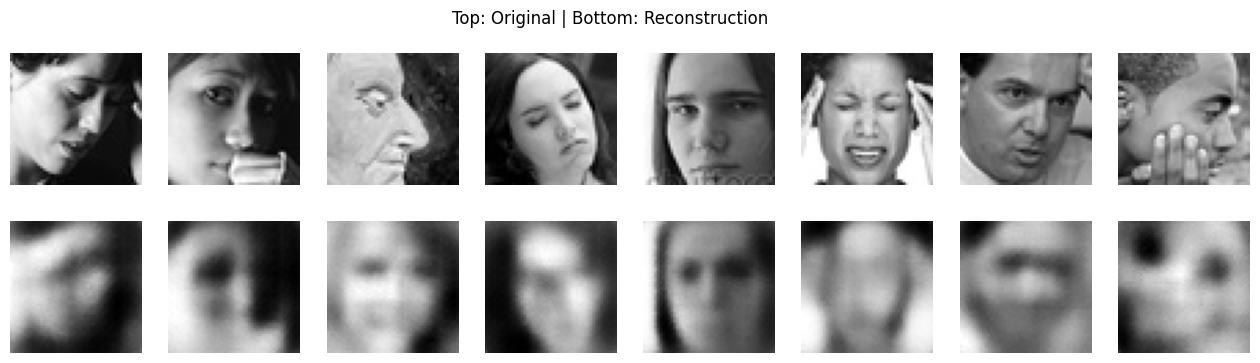

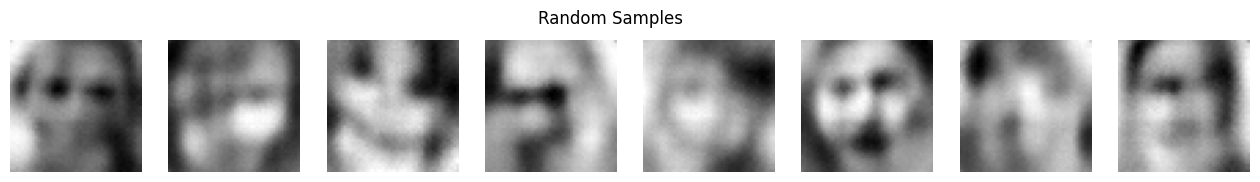

Epoch 002 | beta=0.533 | train: total=1364.7779, recon=1338.4304, kl=49.4016 | val: total=1364.1261, recon=1335.6470, kl=53.3984
Epoch 003 | beta=0.800 | train: total=1370.6083, recon=1338.4057, kl=40.2532 | val: total=1367.1371, recon=1334.1733, kl=41.2048
Epoch 004 | beta=1.067 | train: total=1377.0913, recon=1341.2021, kl=33.6461 | val: total=1375.7027, recon=1339.6639, kl=33.7864
Epoch 005 | beta=1.333 | train: total=1381.4359, recon=1342.7298, kl=29.0295 | val: total=1380.5757, recon=1343.2082, kl=28.0256
Epoch 006 | beta=1.600 | train: total=1387.7624, recon=1347.1251, kl=25.3983 | val: total=1387.1345, recon=1346.2116, kl=25.5768
Epoch 007 | beta=1.867 | train: total=1393.3438, recon=1351.2413, kl=22.5549 | val: total=1395.5377, recon=1351.8379, kl=23.4106
Epoch 008 | beta=2.133 | train: total=1397.2645, recon=1353.6120, kl=20.4621 | val: total=1396.4308, recon=1352.7516, kl=20.4746
Epoch 009 | beta=2.400 | train: total=1402.0017, recon=1357.1198, kl=18.7008 | val: total=1401.21

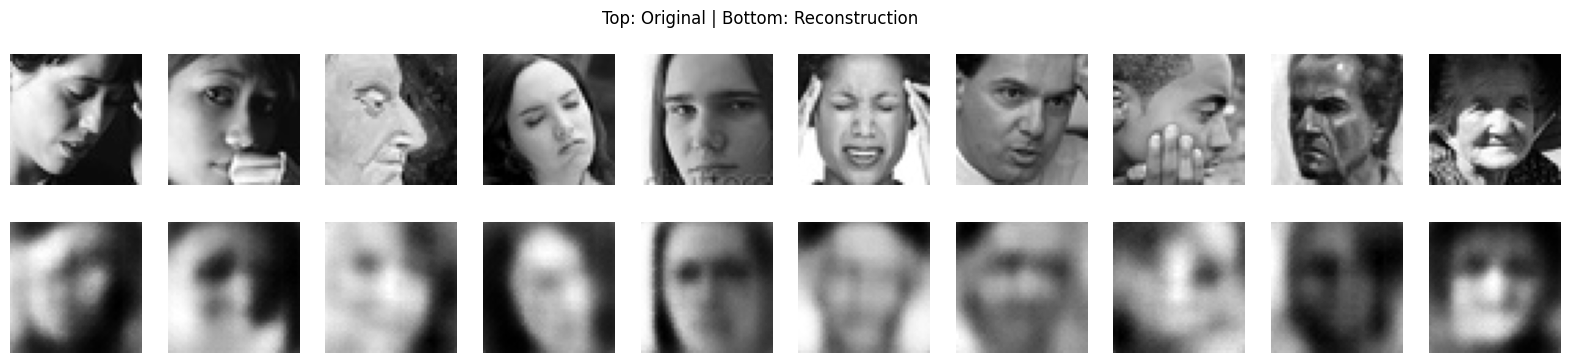

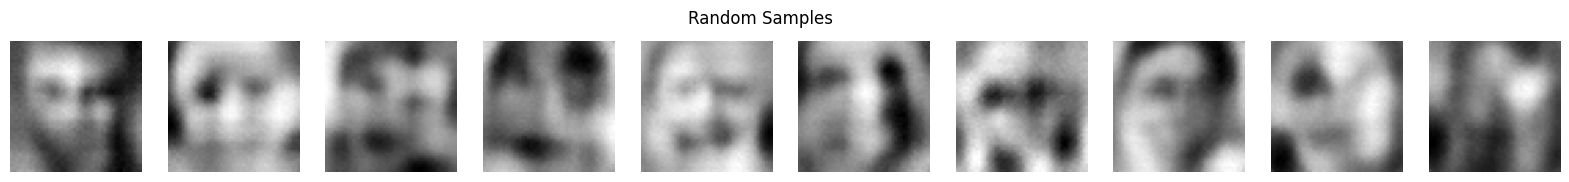

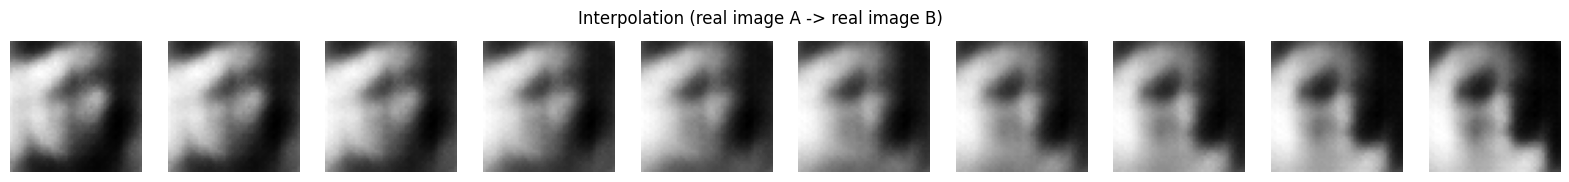

In [13]:
vae = ProVAE(latent_dim=latent_dim)
vae = train_vae(vae, train_loader, val_loader,
                epochs=epochs, lr=lr, beta_final=beta_final, warmup_epochs=warmup_epochs, patience=patience)

show_reconstructions(vae, val_loader, n=10)
show_generated(vae, n=10)
interpolate_real(vae, val_loader, steps=10)

### Optional — Two-phase training (reconstruction pretrain → β-VAE fine-tune)

This function trains the VAE in **two stages** to stabilize learning:

- **Phase 1: Autoencoder-style pretraining (β = 0)**
  - We optimize only the reconstruction term:
    - `BCEWithLogits` between `logits` and `x`
  - Output printed each epoch:
    - average reconstruction loss per sample

- **Phase 2: β-VAE fine-tuning (β warm-up to `beta_target`)**
  - After reconstruction pretraining, we introduce the KL term gradually:
    \[
    \beta = \beta_{target}\cdot \min(1,\frac{ep}{20})
    \]
  - Total loss becomes:
    \[
    \text{loss} = \text{recon} + \beta \cdot KL
    \]
  - A learning-rate scheduler (`ReduceLROnPlateau`) reduces LR when training loss plateaus.

- **Early stopping (training-based)**
  - The function tracks the best **training loss** and stops if it does not improve for 6 epochs.

⚠️ Important note (for report quality)
- Although `val_loader` is passed in, this function currently **does not use validation loss**.
  - This means early stopping selects the best model based on **training loss**, which can overfit.
  - For a stronger report, validation evaluation should be added (similar to `train_vae`), and early stopping should be based on **val loss**.

✅ When to use this
- If your reconstructions are very poor early on, two-phase training can help the model learn “what to reconstruct” first, then gradually learn a structured latent space.


In [14]:
def train_vae_two_phase(model, train_loader, val_loader,
                        pretrain_epochs=15,
                        finetune_epochs=60,
                        beta_target=4.0):

    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2)

    # ========= PHASE 1: Autoencoder Pretrain =========
    print("🔧 Phase 1: Reconstruction Pretraining (β=0)")
    for ep in range(pretrain_epochs):
        model.train()
        total = 0
        for x,_ in train_loader:
            x = x.to(device)
            opt.zero_grad()
            logits, mu, logvar = model(x)
            recon = nn.functional.binary_cross_entropy_with_logits(logits, x, reduction='sum')
            recon.backward()
            opt.step()
            total += recon.item()
        print(f"[Pretrain] Epoch {ep+1} Recon {total/len(train_loader.dataset):.4f}")

    # ========= PHASE 2: VAE Finetune =========
    best = 1e9
    bad = 0
    print("🧠 Phase 2: VAE Finetuning")
    for ep in range(1, finetune_epochs+1):
        beta = beta_target * min(1, ep/20)

        model.train()
        train_loss = 0
        for x,_ in train_loader:
            x = x.to(device)
            opt.zero_grad()
            logits, mu, logvar = model(x)
            recon = nn.functional.binary_cross_entropy_with_logits(logits, x, reduction='sum')
            kl = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
            loss = recon + beta*kl
            loss.backward()
            opt.step()
            train_loss += loss.item()

        train_loss /= len(train_loader.dataset)
        scheduler.step(train_loss)

        print(f"Epoch {ep} β={beta:.2f} loss={train_loss:.4f}")

        if train_loss < best:
            best = train_loss
            bad = 0
            best_state = model.state_dict()
        else:
            bad += 1
            if bad >= 6:
                break

    model.load_state_dict(best_state)
    return model


### Two-phase training run — Results interpretation (pretrain + β-VAE fine-tune)

This cell runs the **two-phase schedule**:
1) **Phase 1:** reconstruction-only pretraining (β = 0)  
2) **Phase 2:** β-VAE fine-tuning with a small target β (`beta_target = 0.2`) and warm-up

---

#### Phase 1 — Reconstruction pretraining (β = 0)
Observed reconstruction loss steadily decreases:

- Epoch 1 recon = **1425.2632**
- Epoch 10 recon = **1300.6111**
- Epoch 20 recon = **1297.3893**

✅ Interpretation:
- The model quickly learns to reconstruct the dataset.
- Improvements become smaller after ~10 epochs, suggesting recon learning is approaching a plateau.

---

#### Phase 2 — β-VAE fine-tuning (β warm-up → 0.2)
During fine-tuning, β increases gradually (very small early values):

- Epoch 1: β=0.01, loss = **1304.1083**
- Epoch 2: β=0.02, loss = **1302.9812**
- Epoch 3: β=0.03, loss = **1303.9932**
- Epoch 8: β=0.08, loss = **1307.4374**

✅ Interpretation:
- As β increases, the model is increasingly penalized by the **KL term**.
- It is normal to see the **total loss increase** as KL regularization strengthens (even if recon stays similar), because:
  \[
  \text{loss} = \text{recon} + \beta \cdot KL
  \]
- The slight upward trend in total loss suggests the model is trading off reconstruction quality for a more regularized / smoother latent space.

📌 Key takeaway:
- **Pretraining improves recon stability**
- **Introducing KL (even small β) increases total loss**, which is expected in β-VAE training.

---

#### Note for reporting
This two-phase run is useful evidence for:
- **Part A:** training a VAE successfully
- **Part B:** showing how increasing β introduces stronger regularization (visible in the loss behavior)

(For a stronger report, you can also show recon/samples after Phase 1 vs after Phase 2 to demonstrate the tradeoff visually.)


In [17]:
vae = ProVAE(latent_dim=64)
vae = train_vae_two_phase(vae, train_loader, val_loader,
                          pretrain_epochs=20,
                          finetune_epochs=80,
                          beta_target=0.2)


🔧 Phase 1: Reconstruction Pretraining (β=0)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Pretrain] Epoch 1 Recon 1425.2632
[Pretrain] Epoch 2 Recon 1341.6352
[Pretrain] Epoch 3 Recon 1320.9189
[Pretrain] Epoch 4 Recon 1311.3418
[Pretrain] Epoch 5 Recon 1306.2351
[Pretrain] Epoch 6 Recon 1303.6767
[Pretrain] Epoch 7 Recon 1302.5479
[Pretrain] Epoch 8 Recon 1301.4820
[Pretrain] Epoch 9 Recon 1300.6688
[Pretrain] Epoch 10 Recon 1300.6111
[Pretrain] Epoch 11 Recon 1299.8444
[Pretrain] Epoch 12 Recon 1299.8805
[Pretrain] Epoch 13 Recon 1299.3926
[Pretrain] Epoch 14 Recon 1298.9208
[Pretrain] Epoch 15 Recon 1298.8070
[Pretrain] Epoch 16 Recon 1298.2624
[Pretrain] Epoch 17 Recon 1298.1434
[Pretrain] Epoch 18 Recon 1297.6762
[Pretrain] Epoch 19 Recon 1297.5567
[Pretrain] Epoch 20 Recon 1297.3893
🧠 Phase 2: VAE Finetuning
Epoch 1 β=0.01 loss=1304.1083
Epoch 2 β=0.02 loss=1302.9812
Epoch 3 β=0.03 loss=1303.9932
Epoch 4 β=0.04 loss=1305.0955
Epoch 5 β=0.05 loss=1306.4728
Epoch 6 β=0.06 loss=1305.2836
Epoch 7 β=0.07 loss=1306.1827
Epoch 8 β=0.08 loss=1307.4374


### Qualitative results (after two-phase training): reconstructions + random samples

This cell visualizes the VAE’s performance after training using:
- `show_reconstructions(vae, val_loader, n=10)`
- `show_generated(vae, n=10)`

**1) Reconstructions (Top: Original | Bottom: Reconstruction)**
- The model captures the **overall face layout** (head position, general shading, rough contours).
- Reconstructions are still **blurry** and lack fine details (eyes, mouth edges, texture).
- This blur is expected for VAEs because the KL regularization encourages a smoother latent space and often produces “averaged” outputs.

**2) Random Samples**
- The generated images look **face-like** (correct global structure), showing the latent space learned a meaningful prior-based generator.
- Some samples show clearer facial components than others, but many remain soft/low-detail, consistent with the reconstruction blur.

**Interpretation**
- These plots confirm that:
  - the encoder/decoder are working correctly (reconstruction is meaningful)
  - sampling from \( z \sim \mathcal{N}(0,I) \) produces plausible outputs (generative ability)
- The main limitation is sharpness/detail, which is a common VAE tradeoff—especially when β (KL pressure) is non-zero.

📌 For Part 3B (β-VAE analysis), these visuals are useful evidence that increasing regularization tends to reduce sharpness while improving latent smoothness.


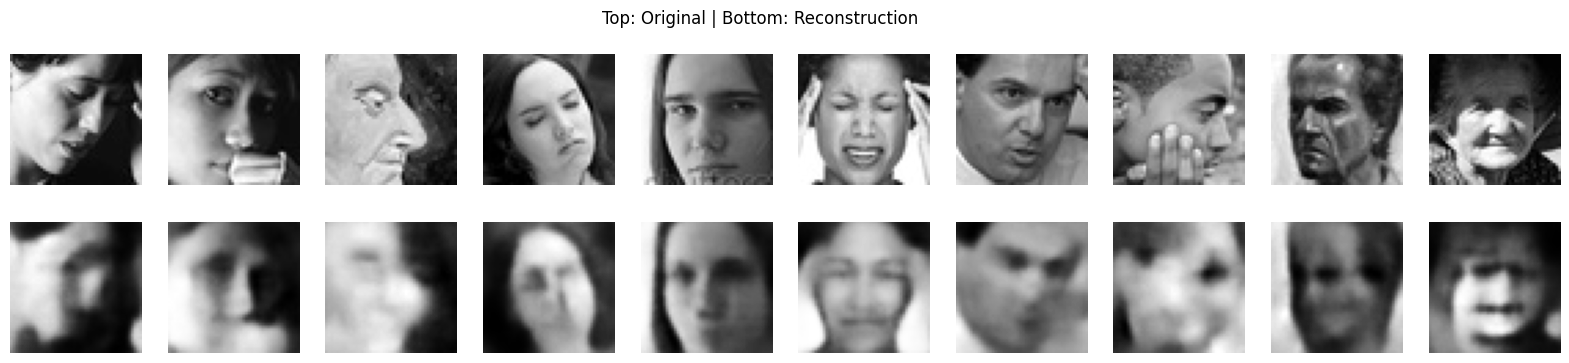

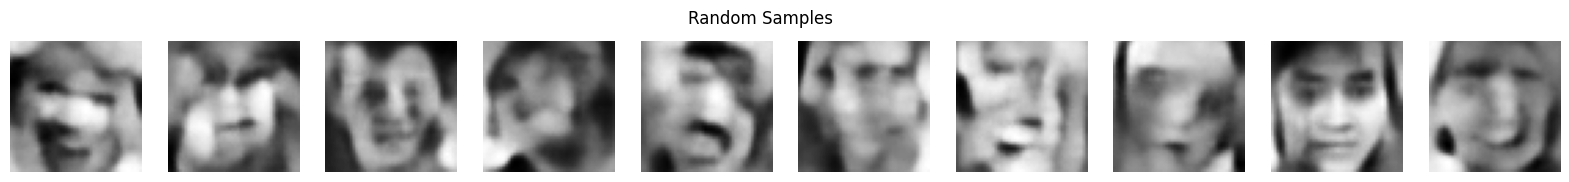

In [18]:
show_reconstructions(vae, val_loader, n=10)
show_generated(vae, n=10)